# Transformer-based Time Series Forecasting
This notebook replaces the LSTM model with a transformer encoder model for forecasting on a dataset containing multiple time series (identified by ID).

In [88]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, LayerNormalization, GlobalAveragePooling1D, MultiHeadAttention
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback
from keras.optimizers import AdamW
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap


In [89]:
print(tf.__version__)

2.19.0


# INPUTS

In [125]:
dynamic_features = ['pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'year_enc', 'day_cos', 'day_sin']
static_features = ['mch_elevation', 'site_enc', 'species_enc']  # static features
features = dynamic_features 
target_column = "twd_rolling30"

features_to_scale = [
    'pr_rolling30', 'at_rolling30', 'ws_rolling30',
    'dp_rolling30', 'sr_rolling30', 'lr_rolling30',
    'day_cos', 'day_sin',
    'mch_elevation', 'twd_rolling30'  # target
]

SEQ_LEN = 7 # number of past time steps the  model uses to make each prediction.
forec_horizon = 1  # number of future time steps to predict
my_patience = 50
my_epochs = 100
checkpoint_frequency = my_epochs //10 # Save a model checkpoint at every 10% of training
my_batch_size = 32
my_val_split = 0.2

## Load and preprocess data

In [91]:
df_ts_series = pd.read_csv('df.ts.series2.csv')
df_ts_series = df_ts_series[df_ts_series['species'] != 'Pseudotsuga menziesii']
#df_ts_series = df_ts_series[df_ts_series['at_rolling30'] >= 0]
df_ts_series 

,Unnamed: 0,site,tree.id,ts,twd,pr,at,ws,dp,sr,...,day.of.year_rolling30,site_longitude,site_latitude,site_easting,site_northing,mch_ind_closest,mch_easting,mch_northing,mch_elevation,mch_site_eucldist
0,1,Bachtel-Forest,1,2020-01-01,0.000000,-4.967054e-09,0.684757,1.197186,-3.640214,62.291590,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
1,2,Bachtel-Forest,1,2020-01-02,0.121408,-1.092752e-07,0.213088,1.312338,-4.036302,60.923900,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
2,3,Bachtel-Forest,1,2020-01-03,0.118271,1.285767e-01,2.009851,2.115951,-0.953911,55.859708,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
3,4,Bachtel-Forest,1,2020-01-04,0.000000,9.927122e-02,1.573278,3.247398,0.721803,13.914832,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
4,5,Bachtel-Forest,1,2020-01-05,0.000000,-1.986821e-08,-0.442240,2.159941,-4.094125,62.620516,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46027,46028,Sihlwald-Forest,42,2020-01-07,0.285428,2.295844e-02,1.842663,2.574209,-0.216778,37.274933,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303
46028,46029,Sihlwald-Forest,42,2020-01-08,0.258344,-6.457170e-07,3.056492,2.483577,-2.625516,47.995854,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303
46029,46030,Sihlwald-Forest,42,2020-01-09,0.509388,-1.182159e-06,4.842269,2.885992,-3.002886,54.513516,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303
46030,46031,Sihlwald-Forest,42,2020-01-10,0.603231,3.270944e-03,4.031820,3.103367,0.587544,39.948842,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303


In [92]:
type(df_ts_series)
print(df_ts_series.columns)
df_ts_series = df_ts_series.dropna(subset=['twd_rolling30'])
print(df_ts_series['twd_rolling30'])

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day.of.year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist'],
      dtype='object')
29       0.565573
30       0.565573
31       0.561526
32       0.557584
33       0.557584
           ...   
46019    0.099176
46020    0.093326
46021    0.101662
46022    0.105229
46023    0.108795
Name: twd_rolling30, Length: 42680, dtype: float64


In [93]:
df_ts_series['site'] = df_ts_series['site'].astype(str)
df_ts_series['year'] = df_ts_series['year'].astype(str)
df_ts_series['species'] = df_ts_series['species'].astype(str)

#encoders = {}
#for col in ['site', 'species', 'year']:
#    le = LabelEncoder()
#    df_ts_series[col + '_enc'] = le.fit_transform(df_ts_series[col])
#    encoders[col] = le

# Proper encoding for categorical features
le_site = LabelEncoder()
le_species = LabelEncoder()

df_ts_series['site_enc'] = le_site.fit_transform(df_ts_series['site'])
df_ts_series['species_enc'] = le_species.fit_transform(df_ts_series['species'])

C:\Users\salom\AppData\Local\Temp\ipykernel_34576\2817426509.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series['site'] = df_ts_series['site'].astype(str)
C:\Users\salom\AppData\Local\Temp\ipykernel_34576\2817426509.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series['year'] = df_ts_series['year'].astype(str)
C:\Users\salom\AppData\Local\Temp\ipykernel_34576\2817426509.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

You map each day to a point on a circle. This way:

- Day 1 and Day 366 end up very close on the circle

- The relationship between days is smooth and continuous

- Models (especially linear or neural nets) can better learn time patterns

366
29    0.492548
30    0.507415
31    0.522133
32    0.536696
33    0.551102
Name: day_sin, dtype: float64


C:\Users\salom\AppData\Local\Temp\ipykernel_34576\3437989156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series.rename(columns={'day.of.year': 'day_of_year'}, inplace=True)
C:\Users\salom\AppData\Local\Temp\ipykernel_34576\3437989156.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series['day_sin'] = np.sin(2 * np.pi * df_ts_series['day_of_year'] / 366)
C:\Users\salom\AppData\Local\Temp\ipykernel_34576\3437989156.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

Text(0.5, 1.0, 'Sine and Cosine of Day of Year')

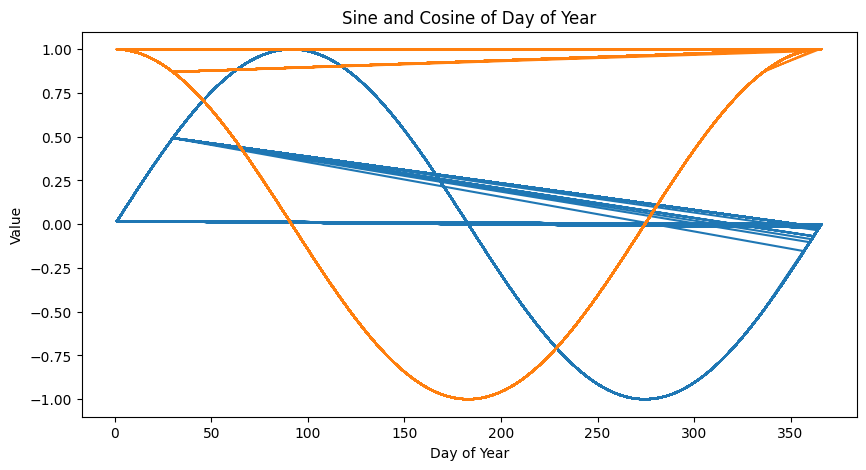

In [94]:
# change column name day.of.year to day_of_year, as numeric
df_ts_series.rename(columns={'day.of.year': 'day_of_year'}, inplace=True)
print(max(df_ts_series['day_of_year']))
df_ts_series['day_sin'] = np.sin(2 * np.pi * df_ts_series['day_of_year'] / 366)
df_ts_series['day_cos'] = np.cos(2 * np.pi * df_ts_series['day_of_year'] / 366)
print(df_ts_series['day_sin'].head())
# plot day_sin and day_cos
plt.figure(figsize=(10, 5))
plt.plot(df_ts_series['day_of_year'], df_ts_series['day_sin'], label='day_sin')
plt.plot(df_ts_series['day_of_year'], df_ts_series['day_cos'], label='day_cos')
plt.xlabel('Day of Year')
plt.ylabel('Value')
plt.title('Sine and Cosine of Day of Year')

In [95]:
print(df_ts_series.columns)
df_ts_series["species_enc"]
# Assume you have these columns
print(df_ts_series['mch_elevation'])
print(df_ts_series['site'] )
print(df_ts_series['site_enc'] )

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day_of_year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist', 'site_enc', 'species_enc', 'day_sin', 'day_cos'],
      dtype='object')
29       882.140575
30       882.140575
31       882.140575
32       882.140575
33       882.140575
            ...    
46019    722.265575
46020    722.265575
46021    722.265575
46022    722.265575
46023    722.265575
Name: mch_elevation, Length: 4

In [96]:
# Initialize dictionary to store scalers
scalers = {}

# Scale each feature individually
for col in features_to_scale:
    scaler = MinMaxScaler()
    df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
    scalers[col] = scaler


C:\Users\salom\AppData\Local\Temp\ipykernel_34576\3433250838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
C:\Users\salom\AppData\Local\Temp\ipykernel_34576\3433250838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
C:\Users\salom\AppData\Local\Temp\ipykernel_34576\3433250838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

## Create input sequences

In [97]:
# fix year
dynamic_scaled_features = [
    f + '_scaled' for f in dynamic_features if f != 'year_enc'
]
static_scaled_features = ['site_enc', 'species_enc', 'mch_elevation_scaled']
target_scaled = target_column + '_scaled'
print(dynamic_scaled_features)
print(static_scaled_features)


['pr_rolling30_scaled', 'at_rolling30_scaled', 'ws_rolling30_scaled', 'dp_rolling30_scaled', 'sr_rolling30_scaled', 'lr_rolling30_scaled', 'day_cos_scaled', 'day_sin_scaled']
['site_enc', 'species_enc', 'mch_elevation_scaled']


In [98]:

def create_sequences(df, seq_len, forecast_horizon=1):
    X_seq, X_static, y, meta = [], [], [], []
    for series_id, group in df.groupby('tree.id'):
        if len(group) < seq_len + forecast_horizon:
            continue
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            window = group.iloc[i:i+seq_len]
            target_window = group.iloc[i+seq_len:i+seq_len+forecast_horizon]
            
            X_seq.append(window[dynamic_scaled_features].values)
            static = group.iloc[i][static_scaled_features].values
            X_static.append(static)
            y.append(target_window[target_scaled].values)

        
            meta.append({
                'tree_id': series_id,
                'site': group.iloc[i]['site'],
                'species': group.iloc[i]['species'],
                'timestamps': window['cum.time.days'].tolist()  # assuming your timestamp column is 'date'
            })
    
    return np.array(X_seq), np.array(X_static), np.array(y), meta


In [99]:
# --- Split by time for each tree ---

# 1. For each tree, split by time (first 80% train, last 20% test)
train_indices, test_indices = [], []

for series_id, group in df_ts_series.groupby('tree.id'):
    group = group.sort_values('cum.time.days')
    n = len(group)
    split_point = int(n * 0.8)
    train_indices.extend(group.index[:split_point])
    test_indices.extend(group.index[split_point:])

df_train = df_ts_series.loc[train_indices].reset_index(drop=True)
df_test = df_ts_series.loc[test_indices].reset_index(drop=True)

# 2. Generate sequences separately for train and test sets
X_seq_train, X_static_train, y_train, meta_train = create_sequences(df= df_train, seq_len = SEQ_LEN, forecast_horizon = forec_horizon)
X_seq_test, X_static_test, y_test, meta_test = create_sequences(df= df_test, seq_len = SEQ_LEN, forecast_horizon = forec_horizon)

In [100]:
tree_info = meta_test[2] # example
print(tree_info['tree_id'], tree_info['site'], tree_info['species'])

1 Bachtel-Forest Fagus sylvatica


In [101]:

max_site_enc = int(df_ts_series['site_enc'].max())
print("Max site_enc:", max_site_enc)
max_species_enc = int(df_ts_series['species_enc'].max())
print("Max species_enc:", max_species_enc)

Max site_enc: 18
Max species_enc: 5


## Define transformer block

R² is not differentiable in a stable way, Use R² only as a monitoring metric during training. R2 pertains to the whole batch, 

If your model predicts forecast_horizon = 7 future steps (i.e., y_pred.shape = (batch_size, 7)), you can compute R² per output like this:

In [102]:
def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)
    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dense(x.shape[-1])(ff_output)
    return LayerNormalization(epsilon=1e-6)(x + ff_output)


In [103]:
def r2_score_per_timestep(y_true, y_pred):
    # Compute R² for each time step separately and return the average
    
    diff = y_true - y_pred
    #tf.print("Shape of y_true:", tf.shape(y_true)) # [31 1]
    # tf.print("Shape of y_pred:", tf.shape(y_pred))  # [31 1]
    
    ss_res = K.sum(K.square(diff), axis=0)
    ss_tot = K.sum(K.square(y_true - K.mean(y_true, axis=0)), axis=0)
    r2 = 1 - (ss_res / (ss_tot + K.epsilon()))
    return K.mean(r2)

## Build and compile the transformer model

In [104]:
n_features = X_seq_test.shape[-1]
print(n_features)

# Inputs
seq_input = Input(shape=(SEQ_LEN, n_features), name='seq_input')
site_input = Input(shape=(1,), name='site')
species_input = Input(shape=(1,), name='species')
mch_input = Input(shape=(1,), name='mch_input')

# Static embeddings
# Always set input_dim = max value in column + 1.
site_emb = Embedding(input_dim= 19, output_dim=2)(site_input)
species_emb = Embedding(input_dim= 6, output_dim=4)(species_input)
site_vec = Flatten()(site_emb)
species_vec = Flatten()(species_emb)

# Positional encoding
positions = tf.range(start=0, limit=SEQ_LEN, delta=1)
pos_embedding = Embedding(input_dim=SEQ_LEN, output_dim=n_features)(positions)
pos_encoded = seq_input + pos_embedding

# Transformer block
x = transformer_block(pos_encoded, head_size=16, num_heads=2, ff_dim=64)
x = GlobalAveragePooling1D()(x)

# Combine with static
static_vec = Concatenate()([site_vec, species_vec, mch_input])
combined = Concatenate()([x, static_vec])

# Output, use RELU or softplus to avoid negative values
# forecast of the next time step (1-step-ahead).
output = Dense(forec_horizon, activation='softplus')(combined)

optimizer = AdamW(learning_rate=1e-4, weight_decay=1e-5)
model = Model(inputs=[seq_input, mch_input, site_input, species_input], outputs=output)
model.compile(
    optimizer=optimizer,
     # Still use MSE or MAE for training
    loss='mse',
    metrics=[r2_score_per_timestep]
    )  # You may consider 'mae' for multi-step
model.summary()


8


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 7, 8)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 7, 8)      │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 8)      │      1,128 │ add_21[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_21[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 7, 8)      │          0 │ add_21[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 8)      │         16 │ add_22[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 7, 64)     │        576 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 7, 8)      │        520 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ site (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 7, 8)      │          0 │ layer_normalizat… │
│                     │                   │            │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_21        │ (None, 1, 2)      │         38 │ site[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_22        │ (None, 1, 4)      │         24 │ species[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 8)      │         16 │ add_23[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 2)         │          0 │ embedding_21[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 4)         │          0 │ embedding_22[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mch_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 8)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 7)         │          0 │ flatten_14[0][0], │
│ (Concatenate)       │                   │            │ flatten_15[0][0]

 Total params: 2,334 (9.12 KB)

 Trainable params: 2,334 (9.12 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [105]:
X_static_train

array([[np.int64(0), np.int64(2), np.float64(0.30634938285332924)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924)],
       ...,
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548)]],
      dtype=object)

In [106]:
features_to_scale

['pr_rolling30',
 'at_rolling30',
 'ws_rolling30',
 'dp_rolling30',
 'sr_rolling30',
 'lr_rolling30',
 'day_cos',
 'day_sin',
 'mch_elevation',
 'twd_rolling30']

In [107]:
class PeriodicCheckpoint(Callback):
    def __init__(self, save_path, frequency):
        super().__init__()
        self.save_path = save_path
        self.frequency = frequency

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.frequency == 0:
            filepath = os.path.join(self.save_path, f"model_epoch_{epoch+1}.h5")
            self.model.save(filepath)
            print(f"✅ Saved model at epoch {epoch + 1} to {filepath}")

     

In [127]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_callback = PeriodicCheckpoint(save_path=checkpoint_dir, frequency=checkpoint_frequency)       

In [126]:
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience= my_patience,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

In [128]:
history = model.fit(
    {
        'seq_input': X_seq_train,
        'mch_input': X_static_train[:, 2].astype(np.float32),
        'site': X_static_train[:, 0].astype(np.int32),
        'species': X_static_train[:, 1].astype(np.int32),
    },
    y_train,
    validation_split= my_val_split,
    epochs=my_epochs,
    batch_size= my_batch_size,
    callbacks=[early_stopping, checkpoint_callback]
)


Epoch 1/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0074 - r2_score_per_timestep: 0.5459 - val_loss: 0.0465 - val_r2_score_per_timestep: -16756.4473
Epoch 2/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0076 - r2_score_per_timestep: 0.5454 - val_loss: 0.0470 - val_r2_score_per_timestep: -16751.7520
Epoch 3/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0075 - r2_score_per_timestep: 0.5428 - val_loss: 0.0401 - val_r2_score_per_timestep: -13929.7676
Epoch 4/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0077 - r2_score_per_timestep: 0.5407 - val_loss: 0.0501 - val_r2_score_per_timestep: -17666.2832
Epoch 5/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0073 - r2_score_per_timestep: 0.5530 - val_loss: 0.0423 - val_r2_score_per_timestep: -15053.5332
Epoch 6/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0074 - r2_score_per_timestep: 0.5465 - val_loss: 0.0470 - val_r2_score_per_timestep: -15372.5020
Epoch 7/100
846/846 ━━━━━━━━━━━━━━━━━

✅ Saved model at epoch 10 to checkpoints\model_epoch_10.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0072 - r2_score_per_timestep: 0.5676 - val_loss: 0.0588 - val_r2_score_per_timestep: -16134.5742
Epoch 11/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0069 - r2_score_per_timestep: 0.5768 - val_loss: 0.0403 - val_r2_score_per_timestep: -13442.6025
Epoch 12/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0071 - r2_score_per_timestep: 0.5813 - val_loss: 0.0412 - val_r2_score_per_timestep: -14085.3369
Epoch 13/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0069 - r2_score_per_timestep: 0.5562 - val_loss: 0.0547 - val_r2_score_per_timestep: -15749.9551
Epoch 14/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0070 - r2_score_per_timestep: 0.5723 - val_loss: 0.0434 - val_r2_score_per_timestep: -14161.1836
Epoch 15/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0069 - r2_score_per_timestep: 0.5708 - val_loss: 0.0459 - val_r2_score_per_timestep:

✅ Saved model at epoch 20 to checkpoints\model_epoch_20.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0069 - r2_score_per_timestep: 0.5767 - val_loss: 0.0456 - val_r2_score_per_timestep: -13309.8066
Epoch 21/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0070 - r2_score_per_timestep: 0.5752 - val_loss: 0.0414 - val_r2_score_per_timestep: -14113.9473
Epoch 22/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0067 - r2_score_per_timestep: 0.5864 - val_loss: 0.0433 - val_r2_score_per_timestep: -13890.7402
Epoch 23/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0067 - r2_score_per_timestep: 0.5779 - val_loss: 0.0346 - val_r2_score_per_timestep: -13372.5918
Epoch 24/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0068 - r2_score_per_timestep: 0.5831 - val_loss: 0.0438 - val_r2_score_per_timestep: -14240.8809
Epoch 25/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0066 - r2_score_per_timestep: 0.5882 - val_loss: 0.0258 - val_r2_score_per_times

✅ Saved model at epoch 30 to checkpoints\model_epoch_30.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0066 - r2_score_per_timestep: 0.5925 - val_loss: 0.0314 - val_r2_score_per_timestep: -12849.4961
Epoch 31/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0068 - r2_score_per_timestep: 0.5828 - val_loss: 0.0368 - val_r2_score_per_timestep: -15051.0830
Epoch 32/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0068 - r2_score_per_timestep: 0.5969 - val_loss: 0.0303 - val_r2_score_per_timestep: -14098.2520
Epoch 33/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0067 - r2_score_per_timestep: 0.5924 - val_loss: 0.0267 - val_r2_score_per_timestep: -13871.3936
Epoch 34/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0067 - r2_score_per_timestep: 0.5848 - val_loss: 0.0301 - val_r2_score_per_timestep: -13225.7822
Epoch 35/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0066 - r2_score_per_timestep: 0.5918 - val_loss: 0.0263 - val_r2_score_per_tim

✅ Saved model at epoch 40 to checkpoints\model_epoch_40.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0065 - r2_score_per_timestep: 0.6032 - val_loss: 0.0273 - val_r2_score_per_timestep: -15278.5391
Epoch 41/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0063 - r2_score_per_timestep: 0.5994 - val_loss: 0.0216 - val_r2_score_per_timestep: -13484.7295
Epoch 42/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0064 - r2_score_per_timestep: 0.6098 - val_loss: 0.0168 - val_r2_score_per_timestep: -12302.9756
Epoch 43/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0066 - r2_score_per_timestep: 0.6057 - val_loss: 0.0196 - val_r2_score_per_timestep: -12826.3809
Epoch 44/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0066 - r2_score_per_timestep: 0.6052 - val_loss: 0.0216 - val_r2_score_per_timestep: -13447.6660
Epoch 45/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0063 - r2_score_per_timestep: 0.6075 - val_loss: 0.0172 - val_r2_score_pe

...

✅ Saved model at epoch 60 to checkpoints\model_epoch_60.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0064 - r2_score_per_timestep: 0.6100 - val_loss: 0.0114 - val_r2_score_per_timestep: -12033.3594
Epoch 61/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0064 - r2_score_per_timestep: 0.6236 - val_loss: 0.0103 - val_r2_score_per_timestep: -13437.1982
Epoch 62/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0059 - r2_score_per_timestep: 0.6213 - val_loss: 0.0112 - val_r2_score_per_timestep: -11514.7998
Epoch 63/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0062 - r2_score_per_timestep: 0.6107 - val_loss: 0.0122 - val_r2_score_per_timestep: -12716.9414
Epoch 64/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0062 - r2_score_per_timestep: 0.6120 - val_loss: 0.0128 - val_r2_score_per_timestep: -13112.5664
Epoch 65/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0063 - r2_score_per_timestep: 0.6130 - val_loss: 0.0100 - val_r2_score_per_t

✅ Saved model at epoch 70 to checkpoints\model_epoch_70.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0064 - r2_score_per_timestep: 0.6106 - val_loss: 0.0094 - val_r2_score_per_timestep: -12571.5986
Epoch 71/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0063 - r2_score_per_timestep: 0.5991 - val_loss: 0.0094 - val_r2_score_per_timestep: -11500.3535
Epoch 72/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0061 - r2_score_per_timestep: 0.6252 - val_loss: 0.0097 - val_r2_score_per_timestep: -11830.9414
Epoch 73/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0062 - r2_score_per_timestep: 0.6194 - val_loss: 0.0095 - val_r2_score_per_timestep: -11798.6152
Epoch 74/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0060 - r2_score_per_timestep: 0.6261 - val_loss: 0.0081 - val_r2_score_per_timestep: -11187.9443
Epoch 75/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0063 - r2_score_per_timestep: 0.6032 - val_loss: 0.0087 - val_r2_score_per_tim

✅ Saved model at epoch 80 to checkpoints\model_epoch_80.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0062 - r2_score_per_timestep: 0.6171 - val_loss: 0.0080 - val_r2_score_per_timestep: -11678.8428
Epoch 81/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0062 - r2_score_per_timestep: 0.6258 - val_loss: 0.0080 - val_r2_score_per_timestep: -12502.0645
Epoch 82/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0062 - r2_score_per_timestep: 0.6165 - val_loss: 0.0084 - val_r2_score_per_timestep: -11342.7520
Epoch 83/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0063 - r2_score_per_timestep: 0.6178 - val_loss: 0.0093 - val_r2_score_per_timestep: -12153.4375
Epoch 84/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0060 - r2_score_per_timestep: 0.6175 - val_loss: 0.0085 - val_r2_score_per_timestep: -13325.3525
Epoch 85/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0061 - r2_score_per_timestep: 0.6227 - val_loss: 0.0083 - val_r2_score_per_time

✅ Saved model at epoch 90 to checkpoints\model_epoch_90.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0061 - r2_score_per_timestep: 0.6360 - val_loss: 0.0089 - val_r2_score_per_timestep: -12801.1543
Epoch 91/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0060 - r2_score_per_timestep: 0.6229 - val_loss: 0.0086 - val_r2_score_per_timestep: -13368.3984
Epoch 92/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0061 - r2_score_per_timestep: 0.6236 - val_loss: 0.0077 - val_r2_score_per_timestep: -13119.8408
Epoch 93/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0060 - r2_score_per_timestep: 0.6287 - val_loss: 0.0078 - val_r2_score_per_timestep: -10255.6494
Epoch 94/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0061 - r2_score_per_timestep: 0.6243 - val_loss: 0.0080 - val_r2_score_per_timestep: -12547.7939
Epoch 95/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0060 - r2_score_per_timestep: 0.6193 - val_loss: 0.0073 - val_r2_score_per_ti

✅ Saved model at epoch 100 to checkpoints\model_epoch_100.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0060 - r2_score_per_timestep: 0.6109 - val_loss: 0.0075 - val_r2_score_per_timestep: -10243.0508


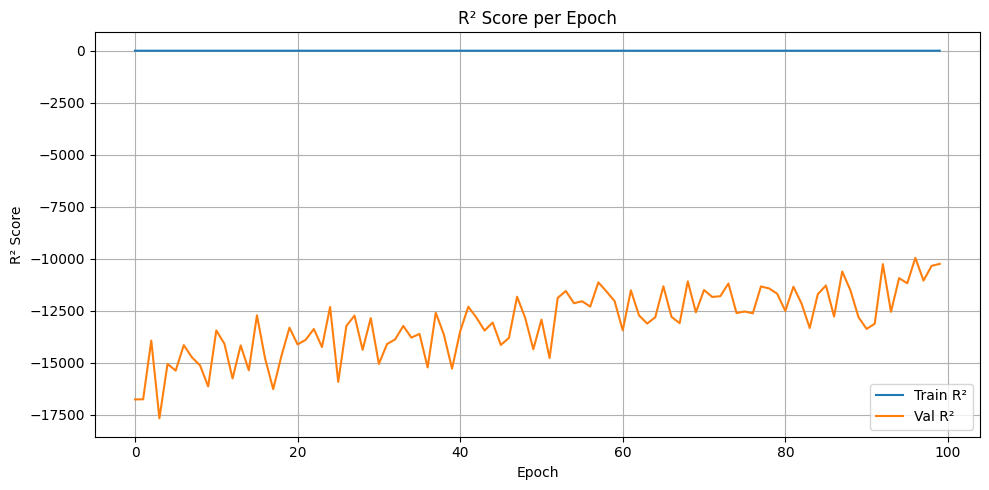

In [129]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['r2_score_per_timestep'], label='Train R²')
plt.plot(history.history['val_r2_score_per_timestep'], label='Val R²')
plt.title("R² Score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [130]:
model.save("transformer_model.h5")

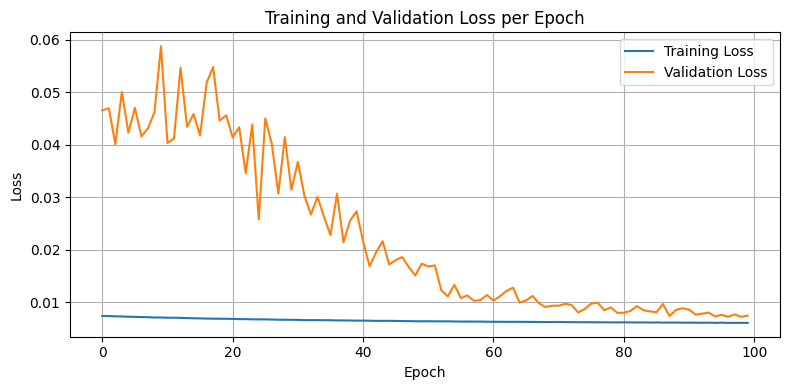

In [131]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluate the model

In [132]:
loss = model.evaluate(
    {
        'seq_input': X_seq_test,
        'mch_input': X_static_test[:, 2].astype(np.float32),
        'site': X_static_test[:, 0].astype(np.int32),
        'species': X_static_test[:, 1].astype(np.int32),
    },
    y_test
)
print("Test Loss:", loss)


259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0132 - r2_score_per_timestep: -1457.5800
Test Loss: [0.014833206310868263, -1443.0185546875]


In [135]:
# Flatten the sequence input
sample_size = 20  # can adjust this
# Flatten seq_input (shape: n, seq_len, n_features) → (n, seq_len * n_features)
seq_flat = X_seq_test.reshape((X_seq_test.shape[0], -1))

# Concatenate with static features (site, species, mch)
X_shap = np.concatenate([seq_flat, X_static_test], axis=1).astype(np.float32)


In [136]:
def model_predict(data):
    n_seq_features = X_seq_test.shape[2]
    seq_len = X_seq_test.shape[1]
    
    seq_input = data[:, :seq_len * n_seq_features].reshape((-1, seq_len, n_seq_features))
    site_input = data[:, seq_len * n_seq_features].astype(np.int32).reshape(-1, 1)
    species_input = data[:, seq_len * n_seq_features + 1].astype(np.int32).reshape(-1, 1)
    mch_input = data[:, seq_len * n_seq_features + 2].astype(np.float32).reshape(-1, 1)
    
    # Return only the prediction for day 3, for example
    return model.predict({
        'seq_input': seq_input,
        'mch_input': mch_input,
        'site': site_input,
        'species': species_input
    })[:, 0]  # Only the 1st day



In [137]:
print(X_shap.shape)
print(SEQ_LEN == X_seq_test.shape[1])
n_dyn = X_seq_test.shape[2]

dynamic_names = [f"{feat}_t{t}" for t in range(SEQ_LEN) for feat in dynamic_scaled_features]
static_names = ['site_enc', 'species_enc', 'mch_scaled']
feature_names = dynamic_names + static_names
print(feature_names)

(8280, 59)
True
['pr_rolling30_scaled_t0', 'at_rolling30_scaled_t0', 'ws_rolling30_scaled_t0', 'dp_rolling30_scaled_t0', 'sr_rolling30_scaled_t0', 'lr_rolling30_scaled_t0', 'day_cos_scaled_t0', 'day_sin_scaled_t0', 'pr_rolling30_scaled_t1', 'at_rolling30_scaled_t1', 'ws_rolling30_scaled_t1', 'dp_rolling30_scaled_t1', 'sr_rolling30_scaled_t1', 'lr_rolling30_scaled_t1', 'day_cos_scaled_t1', 'day_sin_scaled_t1', 'pr_rolling30_scaled_t2', 'at_rolling30_scaled_t2', 'ws_rolling30_scaled_t2', 'dp_rolling30_scaled_t2', 'sr_rolling30_scaled_t2', 'lr_rolling30_scaled_t2', 'day_cos_scaled_t2', 'day_sin_scaled_t2', 'pr_rolling30_scaled_t3', 'at_rolling30_scaled_t3', 'ws_rolling30_scaled_t3', 'dp_rolling30_scaled_t3', 'sr_rolling30_scaled_t3', 'lr_rolling30_scaled_t3', 'day_cos_scaled_t3', 'day_sin_scaled_t3', 'pr_rolling30_scaled_t4', 'at_rolling30_scaled_t4', 'ws_rolling30_scaled_t4', 'dp_rolling30_scaled_t4', 'sr_rolling30_scaled_t4', 'lr_rolling30_scaled_t4', 'day_cos_scaled_t4', 'day_sin_scale

 background = X_shap[:20]: A sample of representative input data used by SHAP to estimate the baseline prediction (i.e., what the model would predict in the absence of specific feature values. You're telling SHAP to use the first 20 samples from your input data as the background set for reference.

In [139]:
# background = X_shap[:20]
background = X_shap[np.random.choice(len(X_shap), 100, replace=False)]
explainer = shap.KernelExplainer(model_predict, background)
#shap_values = explainer.shap_values(X_shap[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [140]:
# === Compute SHAP values ===
# If your model outputs 7 values (7-day forecast), specify ranked_outputs=1 to pick the most important one
# Make sure your input is shaped (samples, features), not (features, samples)
nb_samples_shap = 20
shap_values = explainer.shap_values(X_shap[:nb_samples_shap])  # shape: (5, 183)
print(shap_values.shape)

  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step
1/1 ━━━━━━━━━

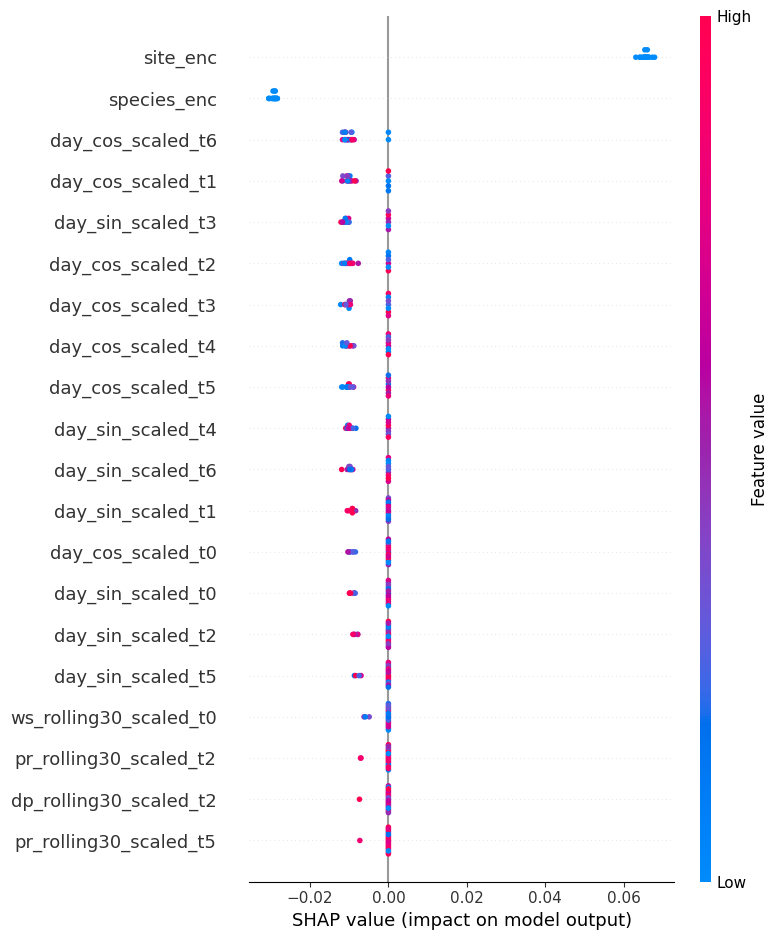

In [141]:
shap.summary_plot(shap_values, X_shap[:nb_samples_shap], feature_names=feature_names)

In [142]:
print("First few target values:", y_train[:10, 0])
print(np.mean(y_train[:, 0]), np.std(y_train[:, 0]))

First few target values: [0.09379683 0.09492678 0.09554407 0.09634139 0.10161685 0.10136749
 0.10088415 0.09948251 0.0953319  0.08928725]
0.12861931268479673 0.1285793004993239


In [143]:
y_pred = model.predict({
    'seq_input': X_seq_test.astype(np.float32),
    'mch_input': X_static_test[:, 2].astype(np.float32).reshape(-1, 1),
    'site': X_static_test[:, 0].astype(np.int32).reshape(-1, 1),
    'species': X_static_test[:, 1].astype(np.int32).reshape(-1, 1),
})


259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [144]:
print("y_pred shape:", y_pred.shape) # Number of sequences
print("Total predicted values:", y_pred.shape[0] * y_pred.shape[1])

y_pred shape: (8280, 1)
Total predicted values: 8280


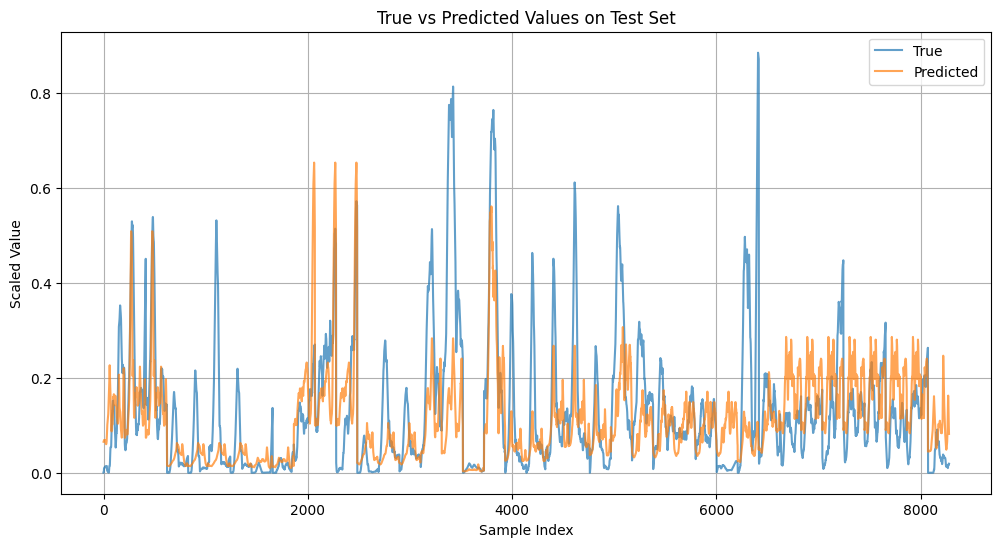

In [145]:
# Plot true vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test[:, 0], label='True', alpha=0.7)
plt.plot(y_pred[:, 0], label='Predicted', alpha=0.7)
plt.title('True vs Predicted Values on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

In [146]:
y_test.shape

(8280, 1)

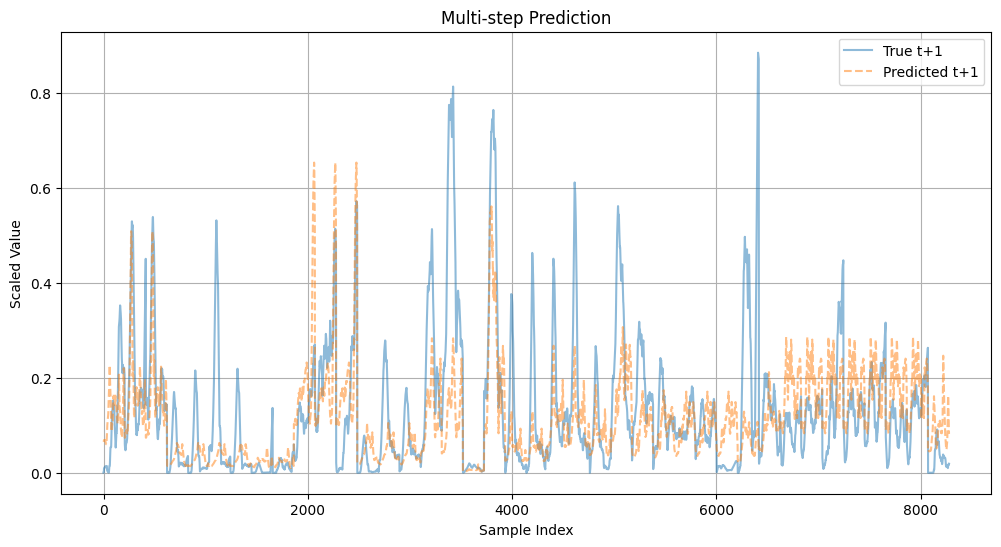

In [147]:
plt.figure(figsize=(12, 6))
for i in range(forec_horizon):
    plt.plot(y_test[:, i], label=f'True t+{i+1}', alpha=0.5)
    plt.plot(y_pred[:, i], label=f'Predicted t+{i+1}', alpha=0.5, linestyle='--')
plt.title('Multi-step Prediction')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

In [148]:
y_pred

array([[0.06526539],
       [0.06612299],
       [0.06701239],
       ...,
       [0.09845083],
       [0.0893477 ],
       [0.08178233]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


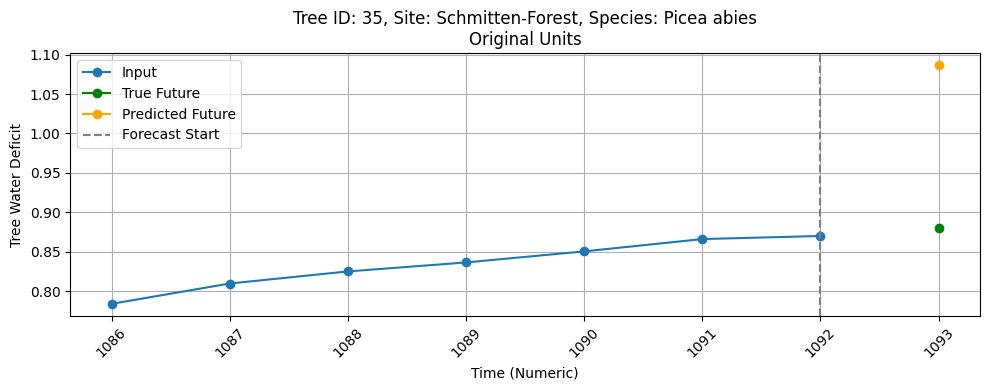

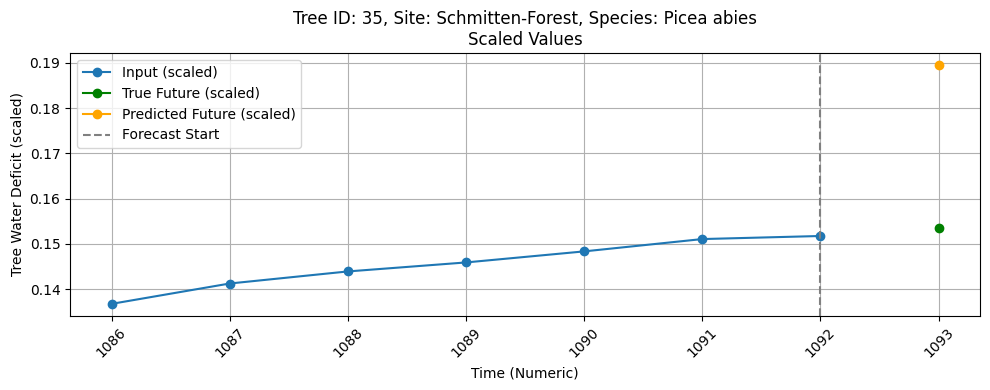

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


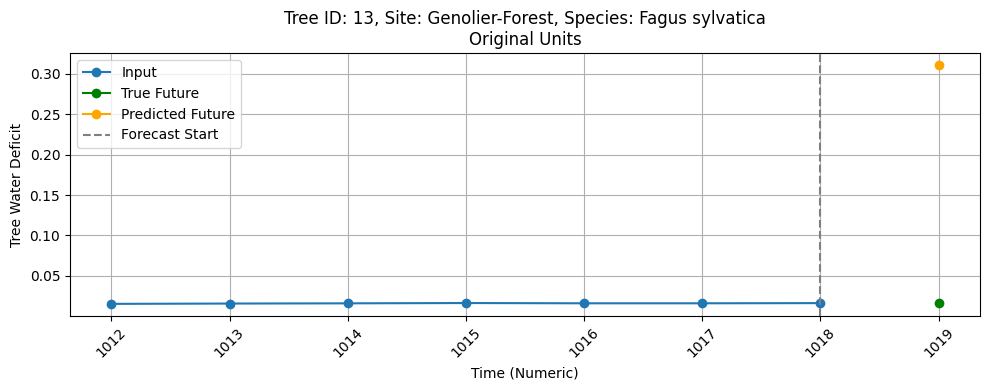

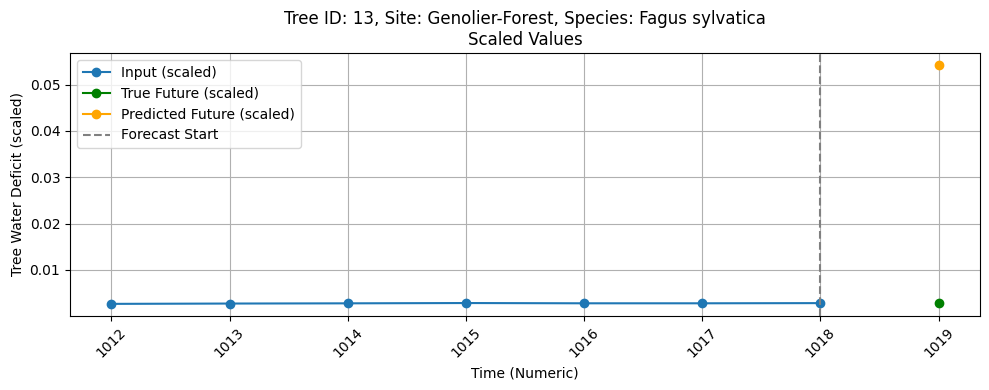

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


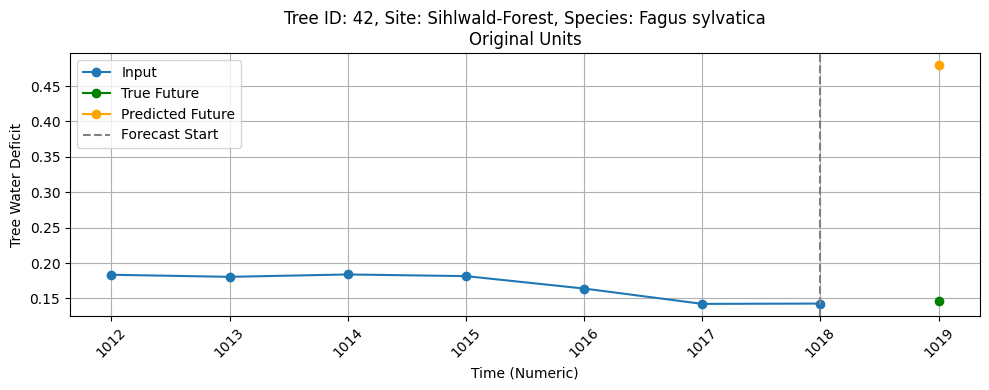

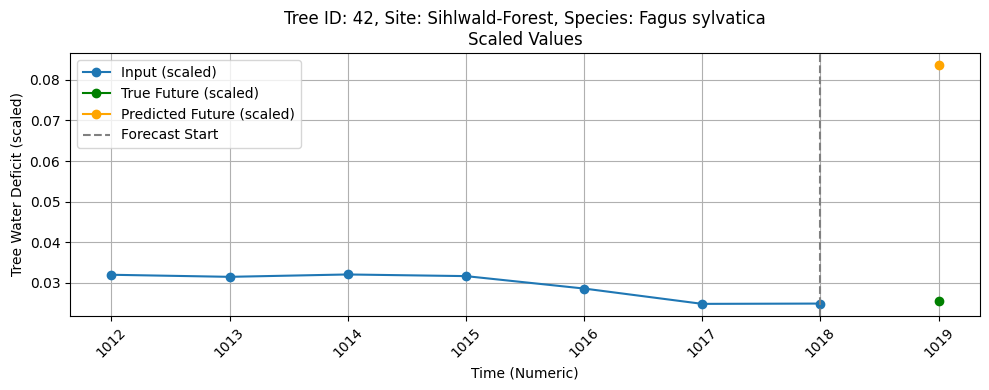

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


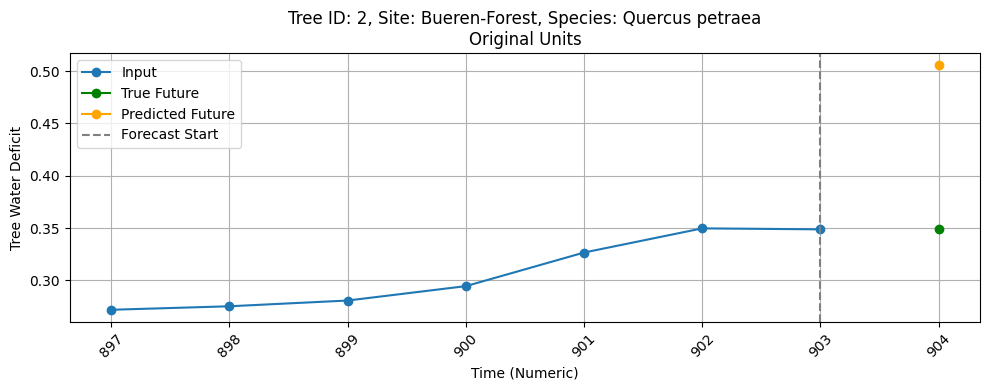

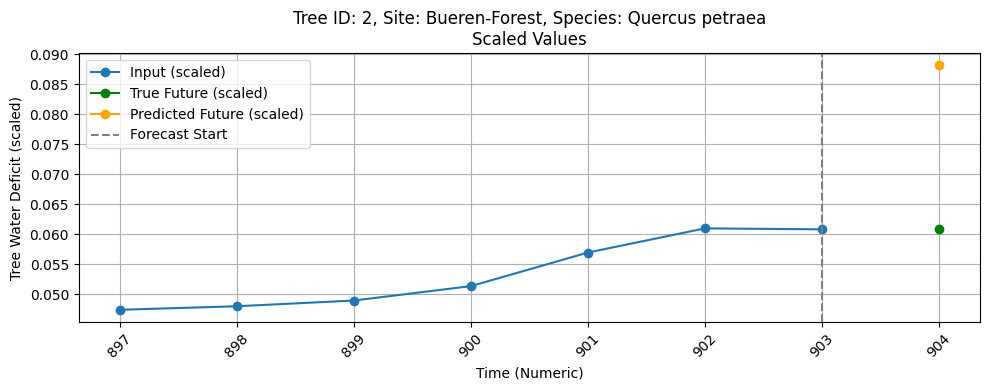

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


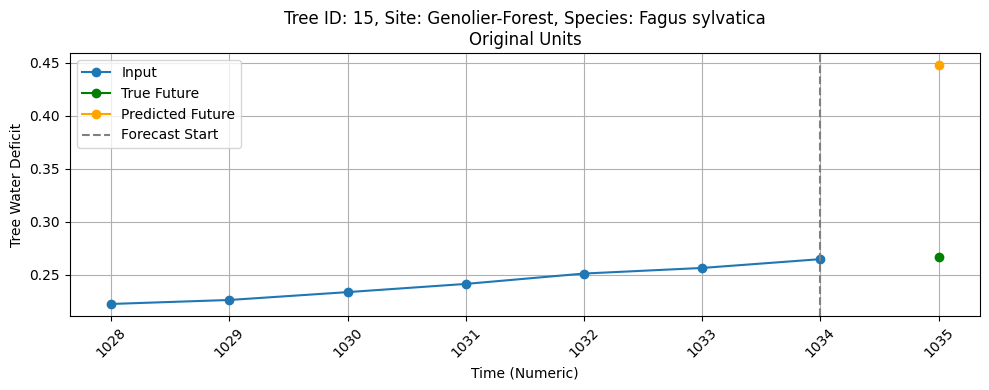

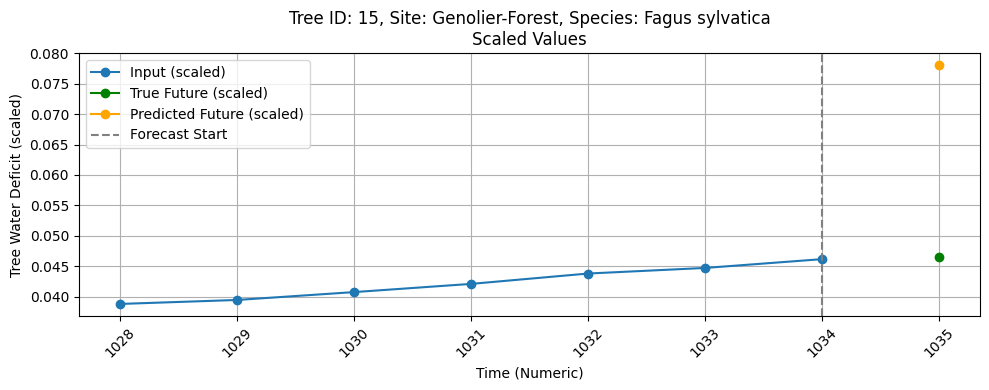

In [149]:
# Pick 5 random indices from the test set
np.random.seed(42)
random_indices = np.random.choice(len(X_seq_test), size=5, replace=False)

for idx in random_indices:
    tree_info = meta_test[idx]
    tree_id = tree_info['tree_id']
    timestamps = tree_info['timestamps']
    last_time = timestamps[-1]
    future_dates = [last_time + i for i in range(1, forec_horizon + 1)]

    # Get the true input sequence from the DataFrame
    mask = (df_ts_series['tree.id'] == tree_id) & (df_ts_series['cum.time.days'].isin(timestamps))
    input_seq_true = df_ts_series.loc[mask, 'twd_rolling30'].values
    input_seq_scaled = df_ts_series.loc[mask, 'twd_rolling30_scaled'].values

    true = y_test[idx]
    pred = model.predict({
        'seq_input': X_seq_test[idx:idx+1],
        'mch_input': X_static_test[idx:idx+1, 2].reshape(-1, 1).astype(np.float32),
        'site': X_static_test[idx:idx+1, 0].reshape(-1, 1).astype(np.int32),
        'species': X_static_test[idx:idx+1, 1].reshape(-1, 1).astype(np.int32),
    })[0]

    scaler = scalers['twd_rolling30']
    true_unscaled = scaler.inverse_transform(true.reshape(-1, 1)).flatten()
    pred_unscaled = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
    input_unscaled = input_seq_true  # Already in original units

    # --- Plot 1: Unscaled (original units) ---
    plt.figure(figsize=(10, 4))
    plt.plot(timestamps, input_unscaled, label="Input", marker='o')
    plt.plot(future_dates, true_unscaled, label="True Future", marker='o', color='green')
    plt.plot(future_dates, pred_unscaled, label="Predicted Future", marker='o', color='orange')
    plt.axvline(x=last_time, linestyle='--', color='gray', label='Forecast Start')
    plt.title(f"Tree ID: {tree_info['tree_id']}, Site: {tree_info['site']}, Species: {tree_info['species']}\nOriginal Units")
    plt.xlabel("Time (Numeric)")
    plt.ylabel("Tree Water Deficit")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    # --- Plot 2: Scaled values ---
    plt.figure(figsize=(10, 4))
    plt.plot(timestamps, input_seq_scaled, label="Input (scaled)", marker='o')
    plt.plot(future_dates, true, label="True Future (scaled)", marker='o', color='green')
    plt.plot(future_dates, pred, label="Predicted Future (scaled)", marker='o', color='orange')
    plt.axvline(x=last_time, linestyle='--', color='gray', label='Forecast Start')
    plt.title(f"Tree ID: {tree_info['tree_id']}, Site: {tree_info['site']}, Species: {tree_info['species']}\nScaled Values")
    plt.xlabel("Time (Numeric)")
    plt.ylabel("Tree Water Deficit (scaled)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [ ]:
print(future_dates)
print(pred_unscaled)

[1035]
[0.3110451]


In [ ]:
print(X_seq_test.shape)
a = X_seq[test_idx]
print(df_ts_series.columns)
#print(df_ts_series['tree.id'])
filtered = df_ts_series[df_ts_series['tree.id'] == 8]
cols = ['site', 'species','cum.time.days', 'twd_rolling30']
filtered2 = filtered[cols]
print(filtered2[(filtered2['cum.time.days'] > 460) & (filtered2['cum.time.days'] < 472)])

meta_test
['pr_rolling30_scaled', 'at_rolling30_scaled', 'ws_rolling30_scaled', 'dp_rolling30_scaled', 'sr_rolling30_scaled', 'lr_rolling30_scaled']
['site_enc', 'species_enc', 'mch_elevation_scaled']


(8280, 7, 6)


NameError: name 'X_seq' is not defined